In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv('../sample_data/Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.info()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [4]:
df.describe()


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [31]:
df_selected = df.loc[2:,['Age','Purchased']]


df_selected

,Age,Purchased
2,26,0
3,27,0
4,19,0
5,27,0
6,27,0
...,...,...
395,46,1
396,51,1
397,50,1
398,36,0


In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df_selected.drop('Purchased',axis=1),df_selected['Purchased'],test_size = 0.3 ,random_state=0)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((279, 2), (120, 2), (279,), (120,))

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [8]:
x_train_scaled

array([[-0.87086357, -1.20547456],
       [-0.29826906, -0.25455771],
       [ 0.75148754,  0.31004916],
       [ 1.03778479,  0.51806222],
       [-0.29826906,  0.31004916],
       [-0.77543115,  0.60721068],
       [ 0.65605512, -1.38377147],
       [-0.10740423,  2.30103131],
       [-0.01197181,  1.32039831],
       [-0.87086357, -0.64086768],
       [ 0.27432545, -0.70029998],
       [ 2.08754139, -0.78944844],
       [-1.44345808,  0.39919762],
       [-0.01197181, -0.28427386],
       [ 1.99210897,  2.21188285],
       [-0.58456632,  0.51806222],
       [-0.01197181, -0.55171923],
       [-0.39370148, -0.75973229],
       [ 0.27432545,  0.1020361 ],
       [ 0.75148754, -1.20547456],
       [-1.92062017,  0.51806222],
       [-0.4891339 , -0.81916459],
       [-1.06172841,  2.03358594],
       [ 0.17889303, -0.34370617],
       [ 0.94235237,  0.63692683],
       [-1.82518775, -1.41348762],
       [ 0.17889303,  0.07231995],
       [-0.29826906, -0.55171923],
       [ 0.17889303,

In [9]:
x_trained_scale = pd.DataFrame(x_train_scaled,columns = x_train.columns)
x_trained_scale.describe()

,Age,EstimatedSalary
count,2.790000e+02,2.790000e+02
mean,-1.846392e-16,-1.400711e-16
std,1.001797e+00,1.001797e+00
min,-1.920620e+00,-1.591785e+00
25%,-7.754312e-01,-7.745904e-01
50%,-1.074042e-01,4.260380e-02
75%,7.514875e-01,5.329203e-01
max,2.087541e+00,2.419896e+00


In [10]:
np.round(x_trained_scale.describe(),1)

,Age,EstimatedSalary
count,279.0,279.0
mean,-0.0,-0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.1,2.4


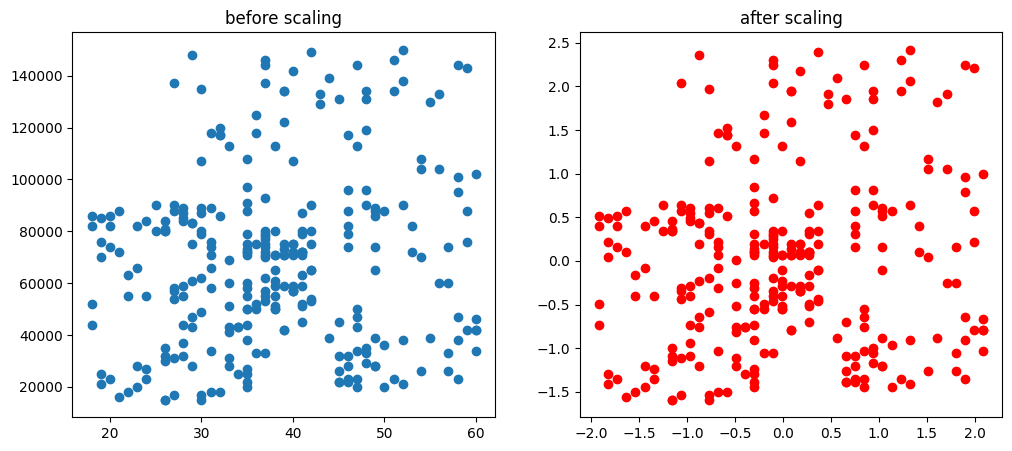

In [11]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title('before scaling')

ax2.scatter(x_trained_scale['Age'],x_trained_scale['EstimatedSalary'],color='red')
ax2.set_title('after scaling')

plt.show()

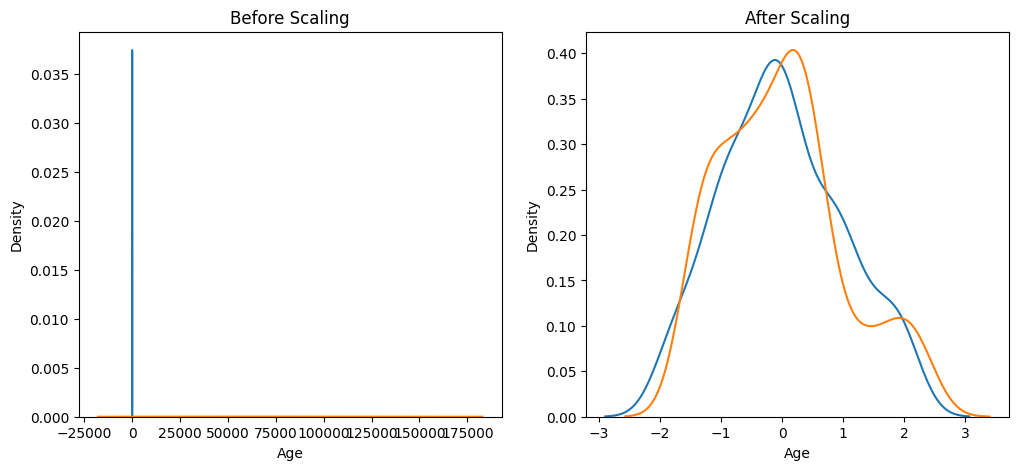

In [12]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize = (12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'],ax = ax1)
sns.kdeplot(x_train['EstimatedSalary'],ax = ax1)

ax2.set_title('After Scaling')
sns.kdeplot(x_trained_scale['Age'],ax = ax2)
sns.kdeplot(x_trained_scale['EstimatedSalary'],ax = ax2)

plt.show()

kde = kernel density estimation

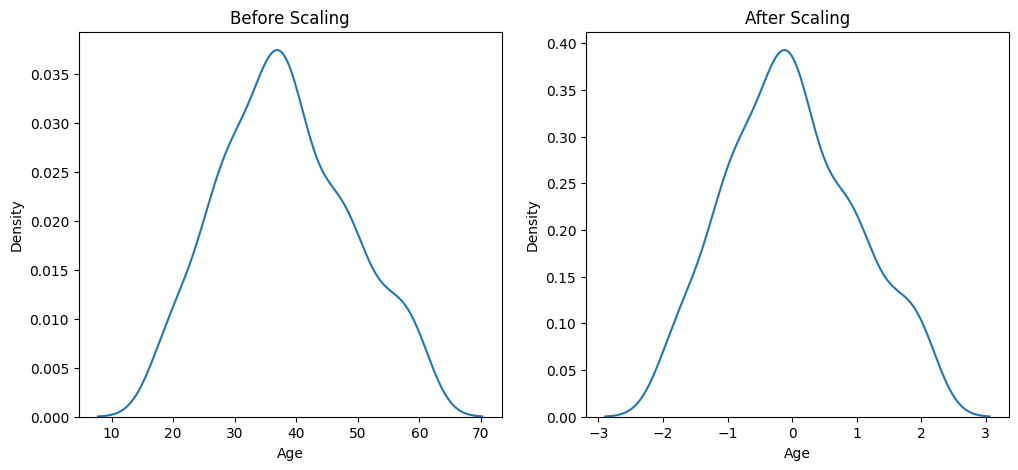

In [13]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize = (12,5))


ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'],ax=ax1)
sns.kdeplot(x_trained_scale['Age'],ax=ax2)

ax2.set_title('After Scaling')
plt.show()

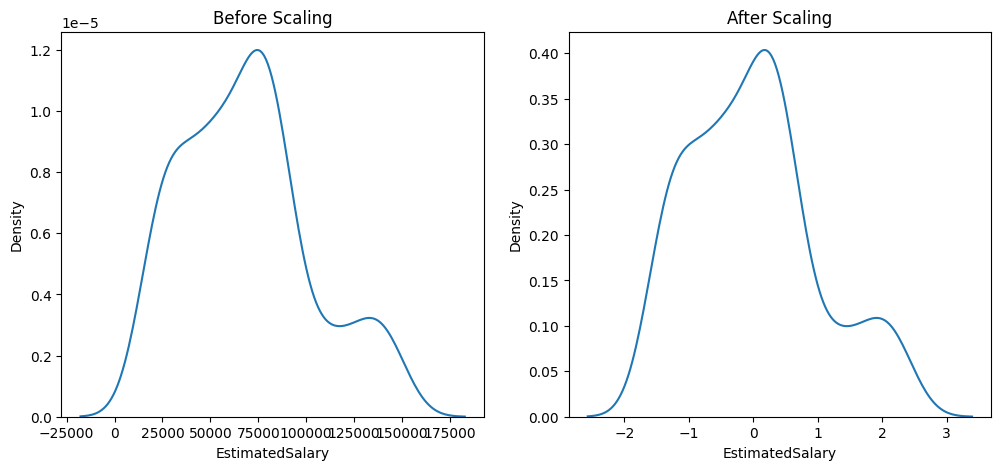

In [14]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(x_trained_scale['EstimatedSalary'],ax=ax2)

plt.show()

#why scaling is important

In [15]:
from sklearn.linear_model import  LogisticRegression
lr_scaled = LogisticRegression()
lr = LogisticRegression()


In [16]:
lr_scaled.fit(x_trained_scale,y_train)
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
pred_scaled = lr_scaled.predict(x_test_scaled)
pred = lr.predict(x_test)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [18]:
from sklearn.metrics import accuracy_score

print('Accuracy of Scaled inputs',accuracy_score(y_test,pred_scaled))
print('Accuracy of Non Scaled inputs',accuracy_score(y_test,pred))

Accuracy of Scaled inputs 0.85
Accuracy of Non Scaled inputs 0.85


effect of outlier

In [19]:
df_out = df.iloc[:,2:]
df_out


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [20]:
df_out = pd.concat([
    df_out,
    pd.DataFrame({
        'Age':[5,90,95],
        'EstimatedSalary':[1000,250000,350000],
        'Purchased':[0,1,1]
    })
], ignore_index=True)



In [21]:
df_out

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


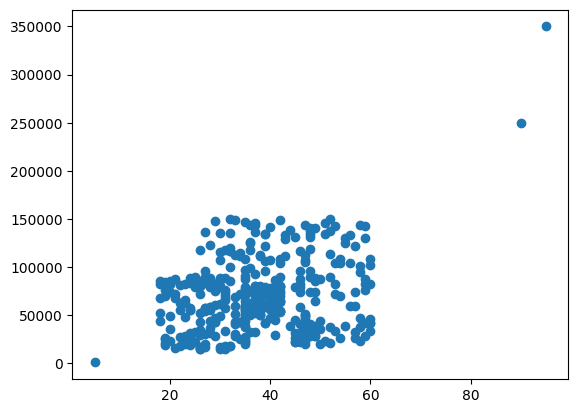

In [22]:
plt.scatter(df_out['Age'],df_out['EstimatedSalary'])

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df_out.drop('Purchased',axis=1),df_out['Purchased'],test_size=0.2,random_state=42)
x_train.shape, x_test.shape

((322, 2), (81, 2))

In [24]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
scale.fit(x_train)
x_train_s = scale.transform(x_train)
x_test_s = scale.transform(x_test)
x_train_s, x_test_s

(array([[-1.08424420e-01, -3.85373407e-01],
        [ 9.68572906e-01,  3.52199225e-01],
        [-1.00592219e+00, -3.85373407e-01],
        [ 6.99323574e-01, -1.12294604e+00],
        [-4.67423529e-01, -1.04664542e+00],
        [ 1.60824911e-01, -3.34506329e-01],
        [ 2.50574689e-01, -3.87032116e-03],
        [-5.57173306e-01,  1.21693955e+00],
        [ 5.19824020e-01, -8.43177110e-01],
        [ 1.23782224e+00,  1.97994572e+00],
        [ 3.40324466e-01, -2.07338634e-01],
        [-8.26422638e-01, -1.12294604e+00],
        [-1.08424420e-01,  1.99597991e-01],
        [-1.09567197e+00,  3.52199225e-01],
        [ 7.10751341e-02, -3.34506329e-01],
        [-1.08424420e-01,  1.82734449e+00],
        [-6.46923083e-01, -2.93038602e-02],
        [-2.87923975e-01, -5.63408180e-01],
        [ 6.99323574e-01,  4.69967569e-02],
        [ 1.77632090e+00,  1.82734449e+00],
        [ 6.99323574e-01,  6.06534616e-01],
        [-3.77673752e-01,  1.01347124e+00],
        [ 7.10751341e-02, -2.930

In [25]:
x_train_saved = pd.DataFrame(x_train_s, columns = x_train.columns)
x_test_saved = pd.DataFrame(x_test_s, columns = x_test.columns)
np.round(x_train_saved.describe(),1)



,Age,EstimatedSalary
count,322.0,322.0
mean,0.0,0.0
std,1.0,1.0
min,-3.0,-1.8
25%,-0.6,-0.7
50%,-0.1,-0.0
75%,0.7,0.4
max,5.1,7.1


In [26]:
np.round(x_test_saved.describe(),1)

,Age,EstimatedSalary
count,81.0,81.0
mean,-0.2,-0.2
std,1.0,0.8
min,-1.8,-1.5
25%,-1.0,-0.7
50%,-0.3,-0.3
75%,0.7,0.3
max,2.0,1.9


mean 0 and std 1 are not gaurenteed for test data

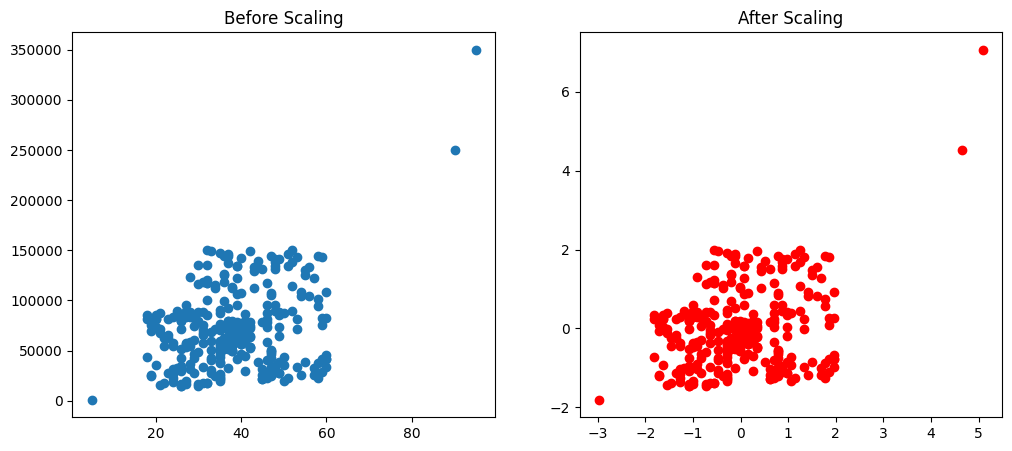

In [27]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_saved['Age'], x_train_saved['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

this means outlierr cant be handeled in standardization
